In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pennylane as qml
from pennylane import numpy as pnp
from tqdm import tqdm
import math
from scipy.stats import truncnorm


In [19]:
# State / family constructors
def rho1(a):
    """Construct a pure-state density matrix for family 1.

    The underlying state is |psi> = [sqrt(1-a^2), 0, a, 0]^T. Returns (rho, label).
    """
    psi1 = pnp.array([pnp.sqrt(1 - a * a), 0.0, a, 0.0], dtype=complex)
    rho = pnp.outer(psi1, pnp.conj(psi1))
    return rho, 1


def rho2(b):
    """Construct the (mixed) density matrix for family 2.

    Family 2 is modeled as the equal mixture of two pure states which differ by
    a relative sign; returns (rho, label=2).
    """
    psi2 = pnp.array([0.0, pnp.sqrt(1 - b * b), b, 0.0], dtype=complex)
    psi3 = pnp.array([0.0, -pnp.sqrt(1 - b * b), b, 0.0], dtype=complex)
    rho = 0.5 * pnp.outer(psi2, pnp.conj(psi2)) + 0.5 * pnp.outer(psi3, pnp.conj(psi3))
    return rho, 2

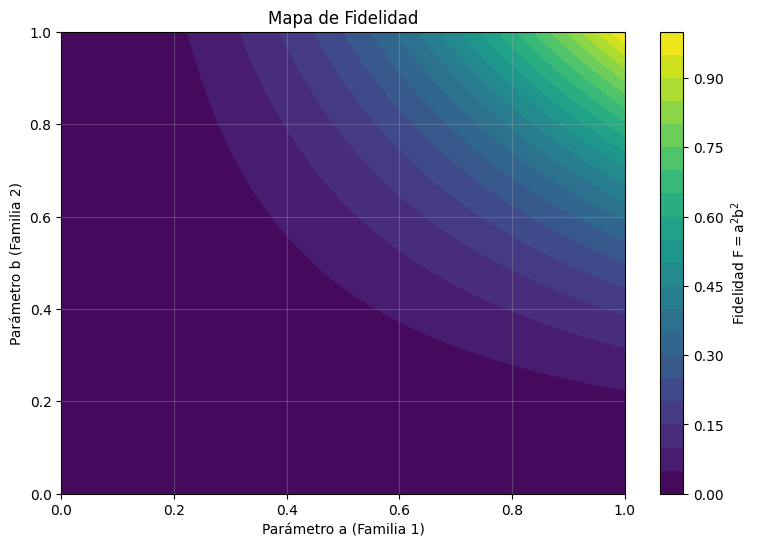

In [20]:
# 1. Mapa de Calor de Fidelidad (F = a^2 * b^2)
# Usamos la fidelidad como proxy visual de la dificultad (F alta = Difícil, F baja = Fácil)
a_grid = np.linspace(0, 1, 100)
b_grid = np.linspace(0, 1, 100)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)
F_grid = (A_grid**2) * (B_grid**2)

plt.figure(figsize=(20, 6))

# Fidelidad
plt.subplot(1, 2, 1)
cp_plot = plt.contourf(A_grid, B_grid, F_grid, levels=20, cmap='viridis')
plt.colorbar(cp_plot, label='Fidelidad $F = a^2 b^2$')
plt.title('Mapa de Fidelidad')
plt.xlabel('Parámetro a (Familia 1)')
plt.ylabel('Parámetro b (Familia 2)')
plt.grid(True, alpha=0.3)

# Distribución Uniforme


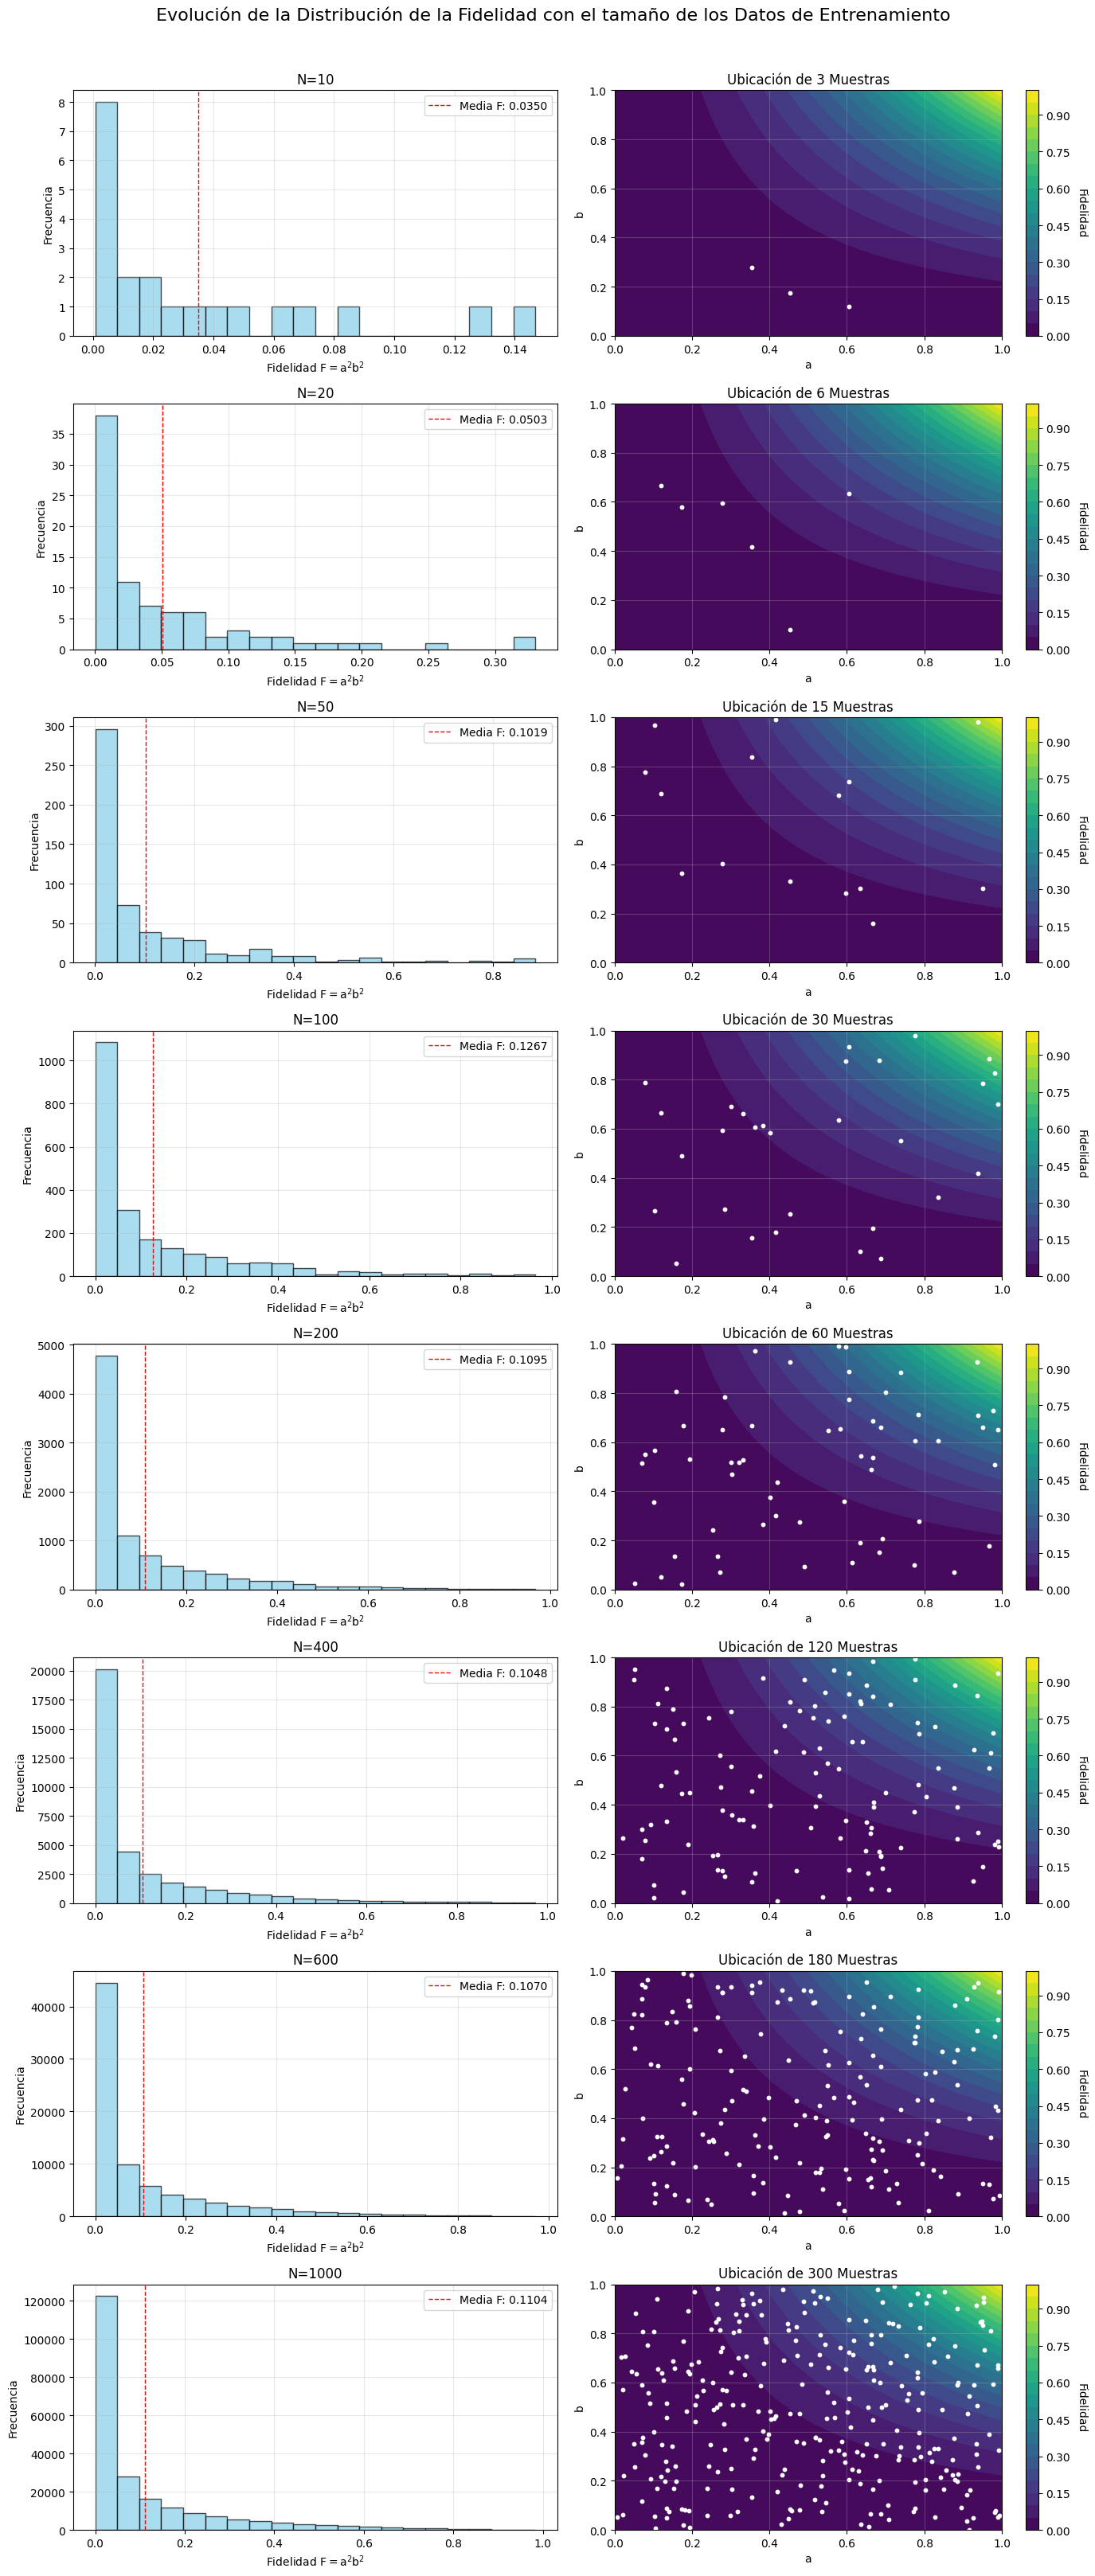

In [21]:
n_samples=[10, 20, 50, 100, 200, 400, 600, 1000]

# Configuración de la figura grande: una fila por cada tamaño de muestra (n)
rows = len(n_samples)
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows)) # Altura ajustada dinámicamente

# Pre-cálculo para el fondo del mapa de calor (es constante)
a_grid = np.linspace(0, 1, 100)
b_grid = np.linspace(0, 1, 100)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)
F_grid = (A_grid**2) * (B_grid**2)

for i, n in enumerate(n_samples):
    np.random.seed(90701)
    a_values = np.random.uniform(0, 1, int(n//3))
    b_values = np.random.uniform(0, 1, math.ceil(n*(2/3)))

    fidelities_dataset = []
    for a in a_values:
        for b in b_values:
            f = (a**2) * (b**2)
            fidelities_dataset.append(f)

    fidelities_dataset = np.array(fidelities_dataset)
    mean_F = np.mean(fidelities_dataset)

    # Selección de ejes para esta fila
    ax_hist = axes[i, 0]
    ax_map = axes[i, 1]

    ax_hist.hist(fidelities_dataset, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_F, color='red', linestyle='dashed', linewidth=1, label=f'Media F: {mean_F:.4f}')
    
    ax_hist.set_title(f'N={n}')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.set_xlabel('Fidelidad $F = a^2 b^2$')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    
    cp = ax_map.contourf(A_grid, B_grid, F_grid, levels=20, cmap='viridis')
    cbar = fig.colorbar(cp, ax=ax_map)
    cbar.set_label('Fidelidad', rotation=270, labelpad=15)

    
    limit = max(1, int(n * 0.3))
    ax_map.scatter(a_values[:limit], b_values[:limit], color='white', s=10)

    ax_map.set_title(f'Ubicación de {limit} Muestras')
    ax_map.set_xlabel('a')
    ax_map.set_ylabel('b')
    ax_map.grid(True, alpha=0.3)

plt.suptitle("Evolución de la Distribución de la Fidelidad con el tamaño de los Datos de Entrenamiento", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

# Distribución Normal

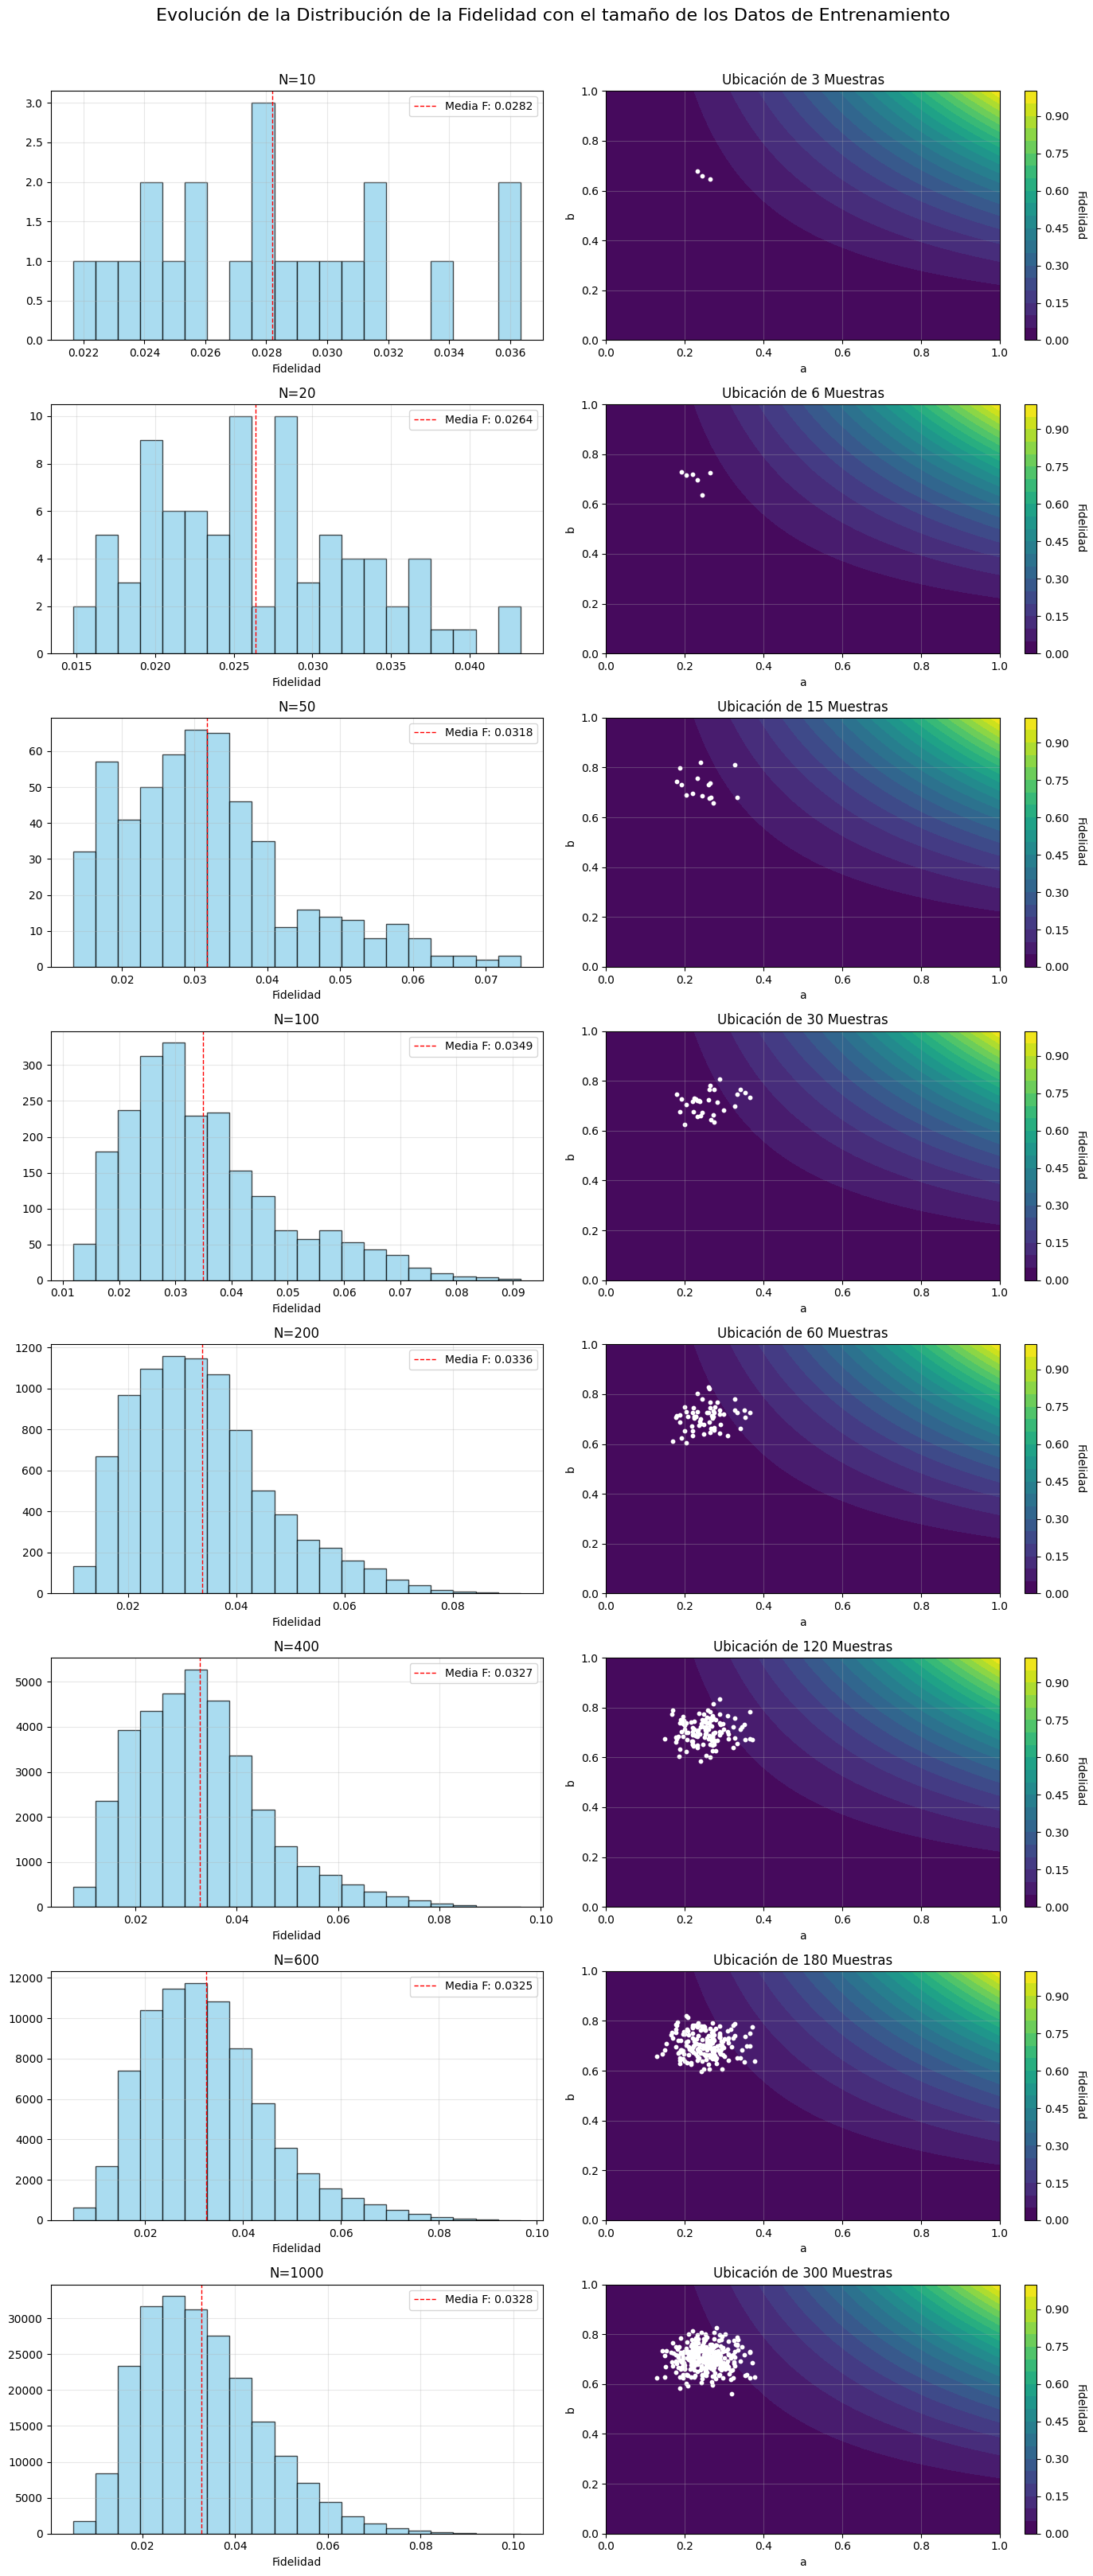

In [22]:
n_samples=[10, 20, 50, 100, 200, 400, 600, 1000]

def sample_truncated_normal(mean, std, size):
    a, b = (0 - mean) / std, (1 - mean) / std
    return truncnorm(a, b, loc=mean, scale=std).rvs(size)

# Configuración de figura grande
rows = len(n_samples)
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))

# Grid constante
a_grid = np.linspace(0, 1, 100)
b_grid = np.linspace(0, 1, 100)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)
F_grid = (A_grid**2) * (B_grid**2)

for i, n in enumerate(n_samples):
    np.random.seed(90701)
    a_values = sample_truncated_normal(mean=0.25, std=0.05, size=n//3)
    b_values = sample_truncated_normal(mean=1/np.sqrt(2), std=0.05, size=math.ceil(n*(2/3)))
    
    fidelities_dataset = []
    for a in a_values:
        for b in b_values:
            f = (a**2) * (b**2)
            fidelities_dataset.append(f)

    fidelities_dataset = np.array(fidelities_dataset)
    mean_F = np.mean(fidelities_dataset)

    # Ejes
    ax_hist = axes[i, 0]
    ax_map = axes[i, 1]

    ax_hist.hist(fidelities_dataset, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_F, color='red', linestyle='dashed', linewidth=1, label=f'Media F: {mean_F:.4f}')
    ax_hist.set_title(f'N={n}')
    ax_hist.set_xlabel('Fidelidad')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    
    cp = ax_map.contourf(A_grid, B_grid, F_grid, levels=20, cmap='viridis')
    cbar = fig.colorbar(cp, ax=ax_map)
    cbar.set_label('Fidelidad', rotation=270, labelpad=15)

    limit = max(1, int(n * 0.3))
    ax_map.scatter(a_values[:limit], b_values[:limit], color='white', s=10)
    
    ax_map.set_title(f'Ubicación de {limit} Muestras')
    ax_map.set_xlabel('a')
    ax_map.set_ylabel('b')
    ax_map.grid(True, alpha=0.3)

plt.suptitle("Evolución de la Distribución de la Fidelidad con el tamaño de los Datos de Entrenamiento", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

# aUniforme bNormal

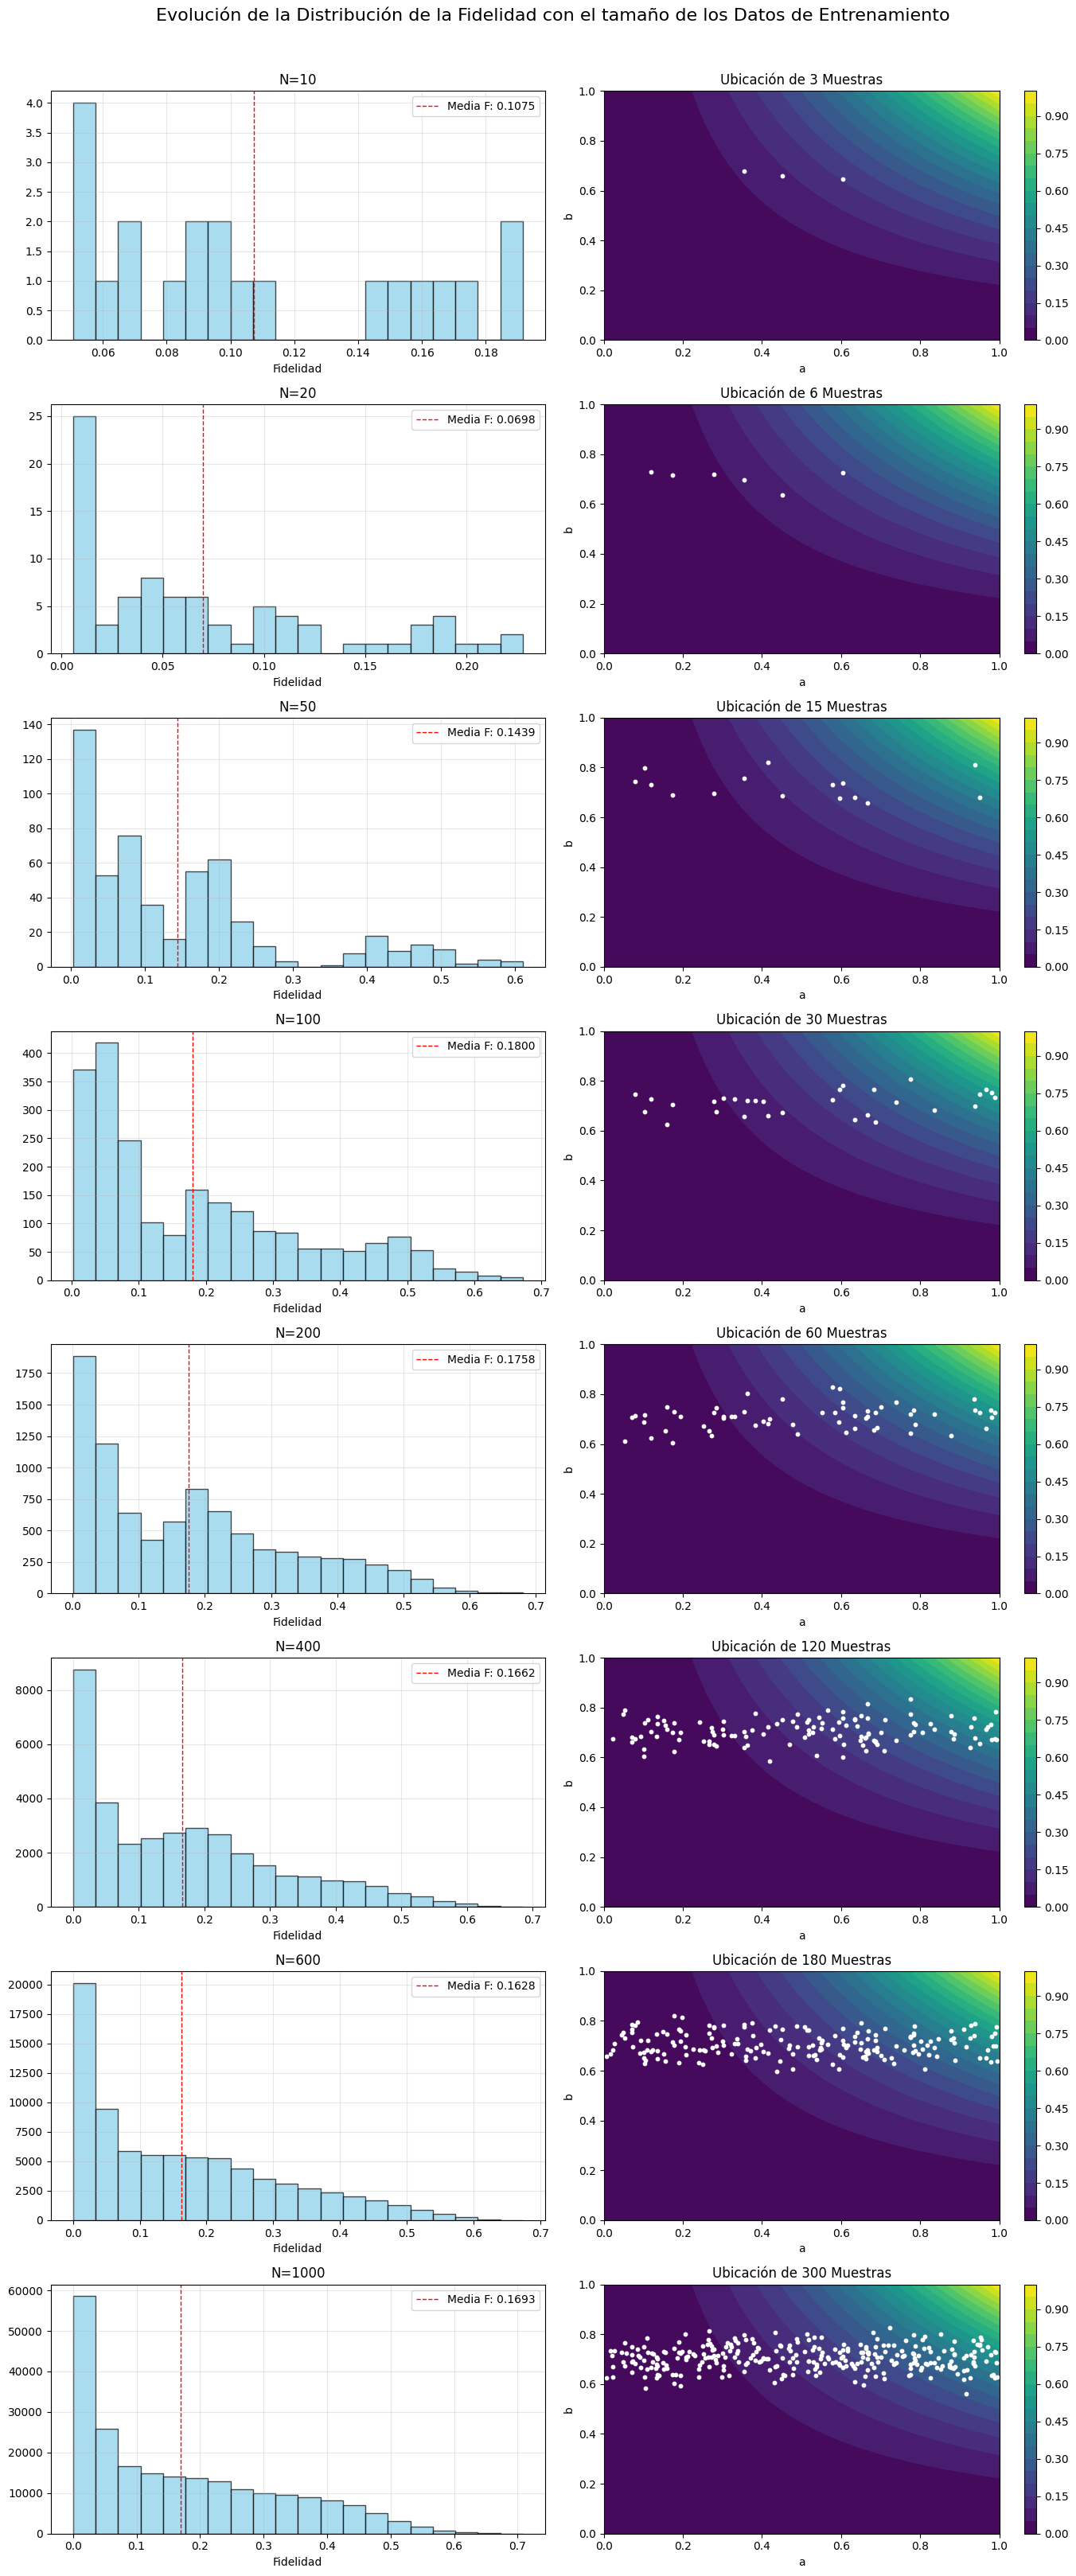

In [23]:
n_samples=[10, 20, 50, 100, 200, 400, 600, 1000]

def sample_truncated_normal(mean, std, size):
    a, b = (0 - mean) / std, (1 - mean) / std
    return truncnorm(a, b, loc=mean, scale=std).rvs(size)

# Figura grande
rows = len(n_samples)
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))

# Grid
a_grid = np.linspace(0, 1, 100)
b_grid = np.linspace(0, 1, 100)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)
F_grid = (A_grid**2) * (B_grid**2)

for i, n in enumerate(n_samples):
    np.random.seed(90701)
    a_values = np.random.uniform(0, 1, int(n//3))
    b_values = sample_truncated_normal(mean=1/np.sqrt(2), std=0.05, size=math.ceil(n*(2/3)))
    
    fidelities_dataset = []
    for a in a_values:
        for b in b_values:
            f = (a**2) * (b**2)
            fidelities_dataset.append(f)

    fidelities_dataset = np.array(fidelities_dataset)
    mean_F = np.mean(fidelities_dataset)

    ax_hist = axes[i, 0]
    ax_map = axes[i, 1]

    # --- Histograma ---
    ax_hist.hist(fidelities_dataset, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_F, color='red', linestyle='dashed', linewidth=1, label=f'Media F: {mean_F:.4f}')
    ax_hist.set_title(f'N={n}')
    ax_hist.set_xlabel('Fidelidad')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # --- Mapa ---
    cp = ax_map.contourf(A_grid, B_grid, F_grid, levels=20, cmap='viridis')
    cbar = fig.colorbar(cp, ax=ax_map)
    
    limit = max(1, int(n * 0.3))
    ax_map.scatter(a_values[:limit], b_values[:limit], color='white', s=10)
    
    ax_map.set_title(f'Ubicación de {limit} Muestras')
    ax_map.set_xlabel('a')
    ax_map.set_ylabel('b')

plt.suptitle("Evolución de la Distribución de la Fidelidad con el tamaño de los Datos de Entrenamiento", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

# aNormal bUniforme

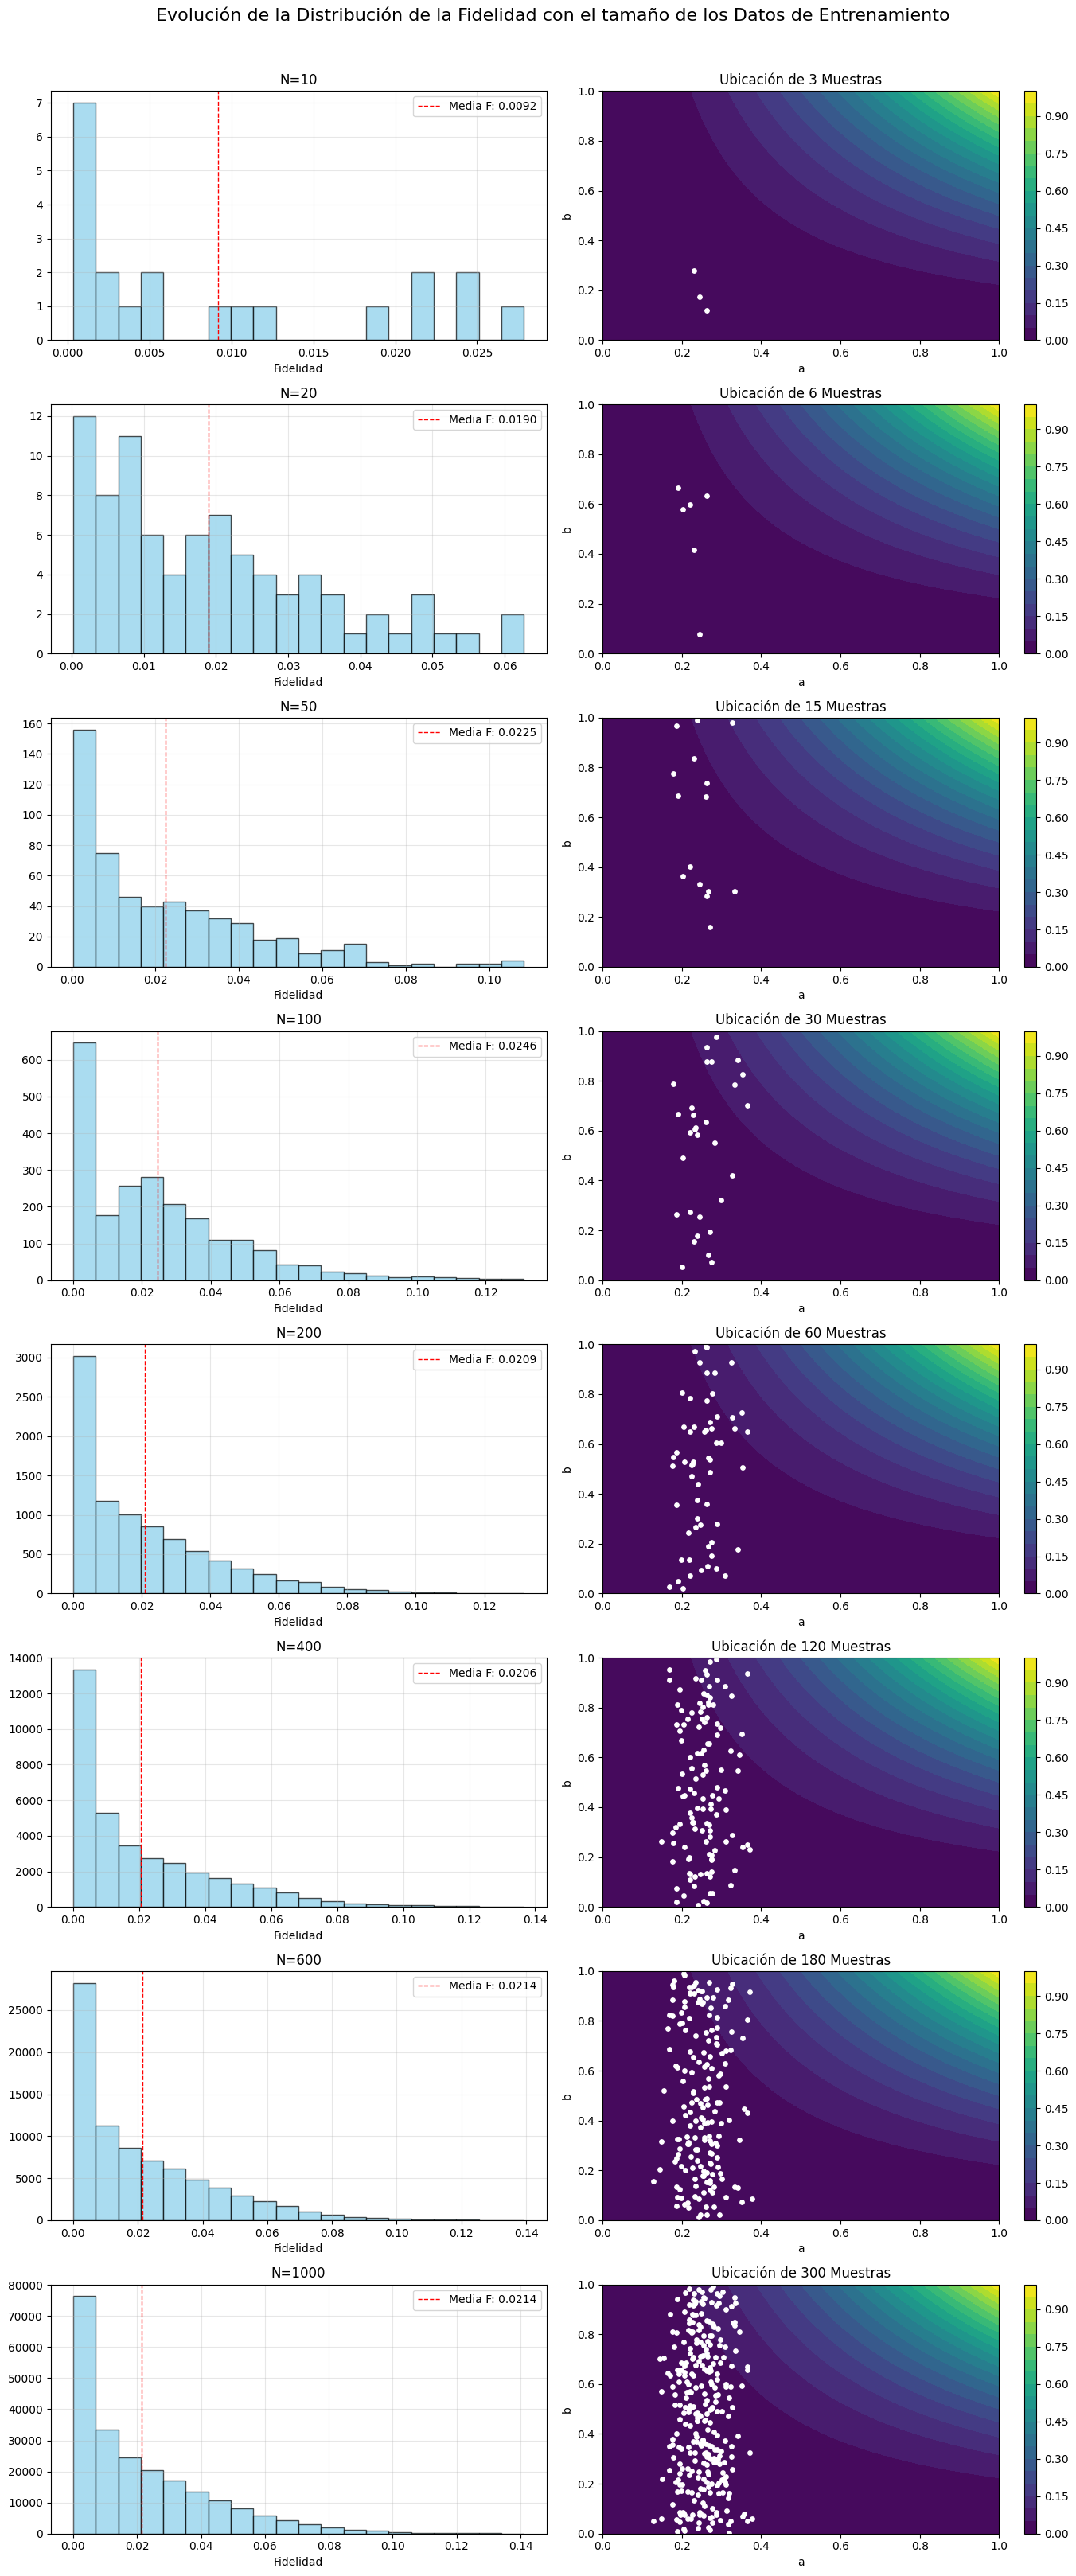

In [24]:
n_samples=[10, 20, 50, 100, 200, 400, 600, 1000]

def sample_truncated_normal(mean, std, size):
    a, b = (0 - mean) / std, (1 - mean) / std
    return truncnorm(a, b, loc=mean, scale=std).rvs(size)

# Figura grande
rows = len(n_samples)
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))

# Grid
a_grid = np.linspace(0, 1, 100)
b_grid = np.linspace(0, 1, 100)
A_grid, B_grid = np.meshgrid(a_grid, b_grid)
F_grid = (A_grid**2) * (B_grid**2)

for i, n in enumerate(n_samples):
    np.random.seed(90701)
    a_values = sample_truncated_normal(mean=0.25, std=0.05, size=n//3)
    b_values = np.random.uniform(0, 1, math.ceil(n*(2/3)))
    
    fidelities_dataset = []
    for a in a_values:
        for b in b_values:
            f = (a**2) * (b**2)
            fidelities_dataset.append(f)

    fidelities_dataset = np.array(fidelities_dataset)
    mean_F = np.mean(fidelities_dataset)

    ax_hist = axes[i, 0]
    ax_map = axes[i, 1]

    # --- Histograma ---
    ax_hist.hist(fidelities_dataset, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_F, color='red', linestyle='dashed', linewidth=1, label=f'Media F: {mean_F:.4f}')
    ax_hist.set_title(f'N={n}')
    ax_hist.set_xlabel('Fidelidad')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # --- Mapa ---
    cp = ax_map.contourf(A_grid, B_grid, F_grid, levels=20, cmap='viridis')
    cbar = fig.colorbar(cp, ax=ax_map)
    
    limit = max(1, int(n * 0.3))
    ax_map.scatter(a_values[:limit], b_values[:limit], color='white', s=15)
    
    ax_map.set_title(f'Ubicación de {limit} Muestras')
    ax_map.set_xlabel('a')
    ax_map.set_ylabel('b')

plt.suptitle("Evolución de la Distribución de la Fidelidad con el tamaño de los Datos de Entrenamiento", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()